In [1]:
from brian2 import *
import numpy as np
from sklearn.datasets import fetch_openml
from tqdm import tqdm

mnist = fetch_openml('mnist_784', data_home='../mnist_data/', as_frame=False, parser='liac-arff')


In [2]:
X_data = mnist.data / 255.0
y_labels = mnist.target.astype(int)

NUM_TRAIN_IMAGES = 60000
X_train = X_data[:NUM_TRAIN_IMAGES]
y_train = y_labels[:NUM_TRAIN_IMAGES]
presentation_time = 350*ms    # 350 ms per image
image_stream = TimedArray(X_train, dt=presentation_time)

In [5]:
defaultclock.dt = 0.5*ms

N_inputs = 28 * 28  
N_outputs = 10 

# Neuron Parameters
tau_m = 20*ms
t_ref = 2*ms 
v_th = 1.0 

# Input LIF Parameters
v_rest_in = 0.0
v_reset_in = -1.0
bias_in = 0.5 

# Output ALIF Parameters
v_rest_out = 0.0
v_reset_out = 0.0
tau_n = 1*second 
inc_n = 0.005 

# VDSP Parameters
lr = 0.01
w_max = 1.0

In [6]:
# Input Layer (LIF)
# input_eqs = '''
# dv/dt = (-v + I_pixel + bias_in) / tau_m : 1 (unless refractory)
# I_pixel : 1
# '''
input_eqs = '''
dv/dt = (-v + I + bias_in) / tau_m : 1 (unless refractory)
I = image_stream(t, i) : 1 
'''

InputLayer = NeuronGroup(N_inputs, input_eqs, threshold='v > v_th', 
                         reset='v = v_reset_in', refractory=t_ref, method='exact')


In [7]:
# Output Layer (Adaptive LIF with WTA Clamping mechanism)
output_eqs = '''
dv/dt = (-v - n) / tau_m : 1 (unless refractory)
dn/dt = -n / tau_n : 1
clamp_release_time : second
'''

OutputLayer = NeuronGroup(N_outputs, output_eqs, threshold='v > v_th and t >= clamp_release_time', 
                          reset='v = v_reset_out; n += inc_n', 
                          refractory=t_ref, method='euler')

# Initialize States
# InputLayer.v = v_rest_in
InputLayer.v = 'v_reset_in + rand() * (v_th - v_reset_in)'
OutputLayer.v = 'v_rest_out + rand() * v_th'
OutputLayer.n = 0.0
OutputLayer.clamp_release_time = 0*ms 

# Feedforward VDSP Synapses
vdsp_model = '''w : 1'''

# Forward transmission: Only add weight if the postsynaptic neuron is NOT clamped
on_pre_forward = 'v_post += w '

# VDSP Learning Rule (Triggered on Postsynaptic Spike)
on_post_vdsp = '''
dw_pot = lr * (w_max - w) * (exp(-v_pre) - 1) * int(v_pre < 0)
dw_dep = lr * w * (exp(v_pre) - 1) * int(v_pre > 0)
w = clip(w + dw_pot - dw_dep, 0.0, w_max)
'''
FeedForward = Synapses(InputLayer, OutputLayer, model=vdsp_model,
                       on_pre=on_pre_forward, on_post=on_post_vdsp,
                        name="feed_forward")
FeedForward.connect() 
FeedForward.w = 'rand() * w_max * 1' # Initialize weights uniformly [0, 1]

# Lateral Inhibition (Winner-Takes-All 10ms Clamp)
wta_pre = '''
v_post = 0
clamp_release_time_post = t + 10*ms
'''
WTA_Synapses = Synapses(OutputLayer, OutputLayer, on_pre=wta_pre)
WTA_Synapses.connect(condition='i != j') 

# Monitors
spike_mon = SpikeMonitor(OutputLayer)


In [8]:
@network_operation(dt=defaultclock.dt, when='thresholds', order=-1)
def enforce_wta(t):
    v       = OutputLayer.v[:]
    t_now   = t / second  
    clamped = OutputLayer.clamp_release_time[:] / second > t_now 
    eligible = (v > v_th) & ~clamped

    if np.sum(eligible) > 1:
        eligible_v     = np.where(eligible, v, -np.inf)
        winner         = int(np.argmax(eligible_v))
        losers         = eligible.copy()
        losers[winner] = False
        for j in np.where(losers)[0]:
            OutputLayer.v[j] = 0.0

In [9]:
# Assemble Network
net = Network(InputLayer, OutputLayer, FeedForward, WTA_Synapses, spike_mon, enforce_wta)

In [13]:
total_training_time = presentation_time * NUM_TRAIN_IMAGES
print(f"Starting continuous simulation for {total_training_time}...")
net.run(total_training_time, report='text', report_period=600*second)

Starting continuous simulation for 21. ks...
Starting simulation at t=0.4118125 ks for a duration of 21. ks
1.182514 ks (5%) simulated in 10m 0s, estimated 2h 47m 35s remaining.
2.361736 ks (11%) simulated in 20m 0s, estimated 2h 37m 50s remaining.
3.5308245 ks (16%) simulated in 30m 0s, estimated 2h 28m 26s remaining.
4.7642045 ks (22%) simulated in 40m 0s, estimated 2h 16m 19s remaining.
6.024203 ks (28%) simulated in 50m 0s, estimated 2h 4m 18s remaining.
7.249973 ks (34%) simulated in 1h 0m 0s, estimated 1h 53m 48s remaining.
8.4692535 ks (40%) simulated in 1h 10m 0s, estimated 1h 43m 34s remaining.
9.6940955 ks (46%) simulated in 1h 20m 0s, estimated 1h 33m 18s remaining.
10.9055 ks (51%) simulated in 1h 30m 0s, estimated 1h 23m 18s remaining.
12.127464 ks (57%) simulated in 1h 40m 0s, estimated 1h 13m 10s remaining.
13.348835 ks (63%) simulated in 1h 50m 0s, estimated 1h 3m 3s remaining.
14.562902 ks (69%) simulated in 2h 0m 0s, estimated 53m 3s remaining.
15.7738645 ks (75%) sim

In [14]:
# for img_idx in tqdm(range(NUM_TRAIN_IMAGES)):
#     InputLayer.I_pixel = X_train[img_idx]
#     net.run(presentation_time)

# print("Training Complete!")

print("Total spikes per output neuron during training:")
print(spike_mon.count[:])

Total spikes per output neuron during training:
[324732 308608 321822 358407 313125 316784 312401 326588 361650 328440]


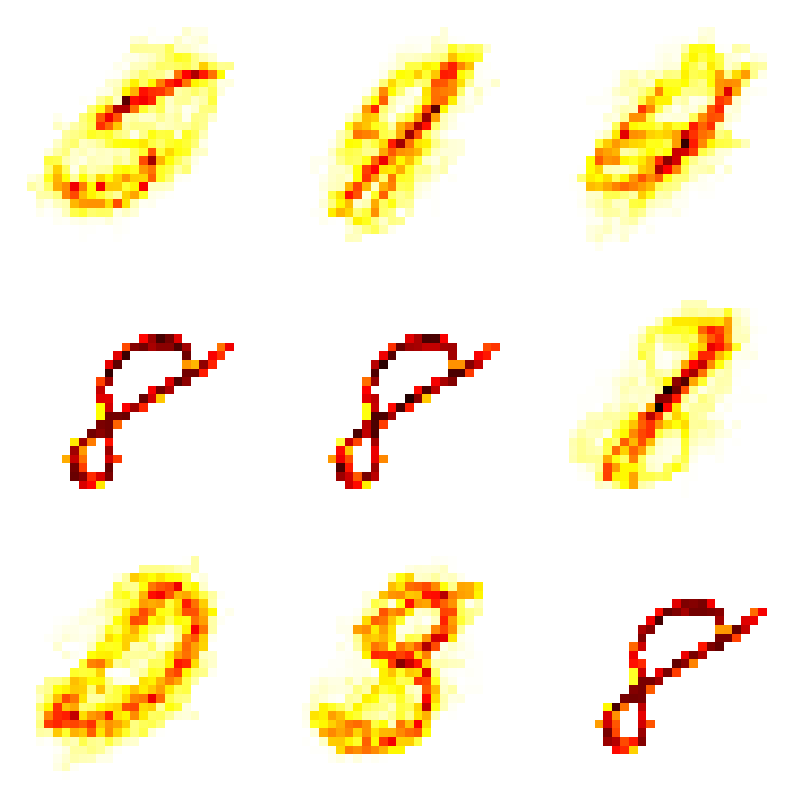

In [15]:
from utils import *
final_weights = get_2d_weights(net['feed_forward'], 28*28, N_outputs)
plot_weights(final_weights, N_outputs)

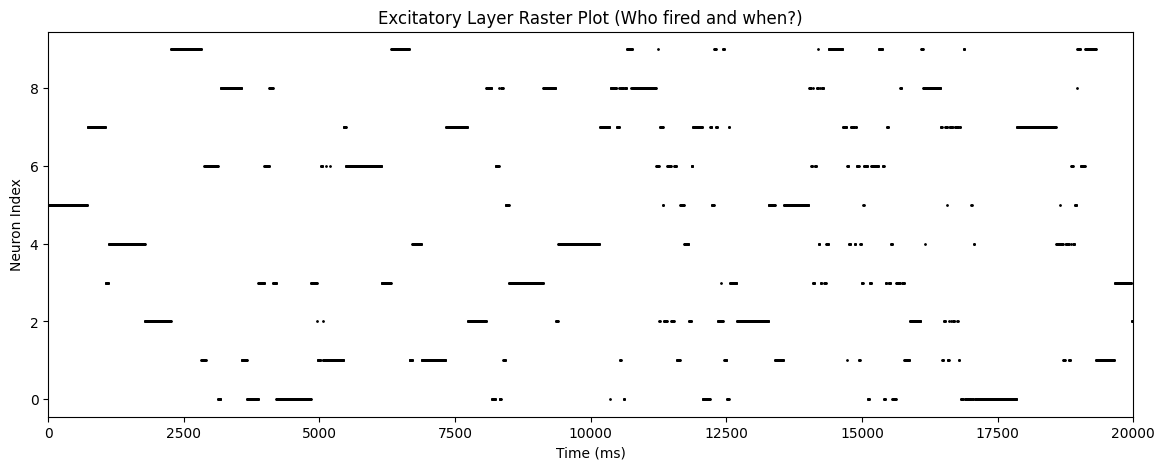

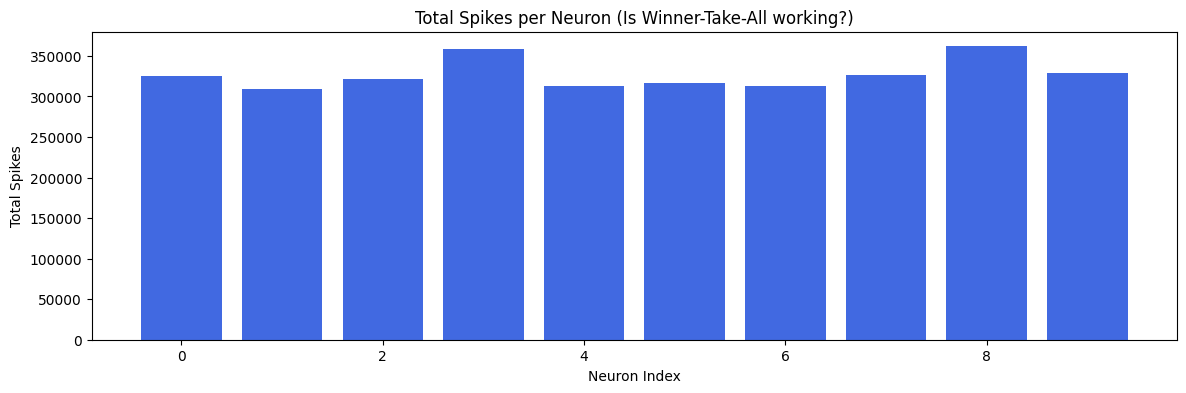

In [16]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 5))
plt.plot(spike_mon.t / ms, spike_mon.i, '.k', markersize=2)
plt.xlabel('Time (ms)')
plt.ylabel('Neuron Index')
plt.title('Excitatory Layer Raster Plot (Who fired and when?)')
plt.xlim(0, 20000) 
plt.show()

plt.figure(figsize=(14, 4))
spike_counts = np.array(spike_mon.count)
plt.bar(range(len(spike_counts)), spike_counts, color='royalblue')
plt.xlabel('Neuron Index')
plt.ylabel('Total Spikes')
plt.title('Total Spikes per Neuron (Is Winner-Take-All working?)')
plt.show()

In [17]:
import os
save_path = '../trained_model/'
if not os.path.exists(save_path):
    os.makedirs(save_path)

trained_weights = np.array(FeedForward.w)
np.save(os.path.join(save_path, 'weights_10.npy'), trained_weights)

trained_n = np.array(OutputLayer.n)
np.save(os.path.join(save_path, 'adaptation_n_10.npy'), trained_n)

print(f"Successfully saved weights and adaptation states to {save_path}")

Successfully saved weights and adaptation states to ../trained_model/


# Testing

In [15]:
from network import *
from utils import *
N_outputs = 10
lr = 0.01      #learning rate
net, InputLayer, FeedForward, OutputLayer, spike_mon = build_network_test(N_outputs,lr)

In [16]:
weights_path = '../trained_model/10/weights.npy'
adaptation_path = '../trained_model/10/adaptation_n.npy'
labels_path = '../trained_model/10/neuron_labels.npy'

FeedForward.w = np.load(weights_path)
OutputLayer.n = np.load(adaptation_path) 
net.store('inference_init')

In [17]:
spike_counts = np.zeros((N_outputs, 10))
num_examples = 1000

for i in tqdm(range(num_examples)):
    
    net.restore('inference_init') # Reset network
    InputLayer.I_pixel = X_train[i]
    current_label = int(y_train[i])
    net.run(presentation_time)
    spike_counts[:, current_label] += spike_mon.count

neuron_labels = np.argmax(spike_counts, axis=1)
dead_neurons = np.sum(spike_counts, axis=1) == 0
neuron_labels[dead_neurons] = -1  # assign -1 to inactive neurons


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [05:48<00:00,  2.87it/s]


In [18]:
num_test_images = 1000
predictions = []
actuals = []

for i in tqdm(range(num_test_images)):
    
    net.restore('inference_init')
    
    true_label = int(y_train[i])
    actuals.append(true_label)
    InputLayer.I_pixel = X_train[i]
    net.run(350 * ms)
    
    class_spikes = np.zeros(10)
    for digit in range(10):
        neurons_in_class = (neuron_labels == digit)
        class_spikes[digit] = np.sum(spike_mon.count[neurons_in_class])
    
    if np.sum(class_spikes) > 0:  
        predicted_label = np.argmax(class_spikes)
    else:
        predicted_label = -1  # Network stayed silent
        
    predictions.append(predicted_label)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [06:08<00:00,  2.72it/s]


In [19]:
predictions = np.array(predictions)
actuals = np.array(actuals)

valid_idx = predictions != -1
correct_predictions = np.sum(predictions[valid_idx] == actuals[valid_idx])
accuracy = (correct_predictions / num_test_images) * 100.0

print(f"\nFinal Accuracy: {accuracy:.2f}% ({correct_predictions} / {num_test_images})")
print(f"Silent Images: {np.sum(predictions == -1)}")


Final Accuracy: 31.60% (316 / 1000)
Silent Images: 0


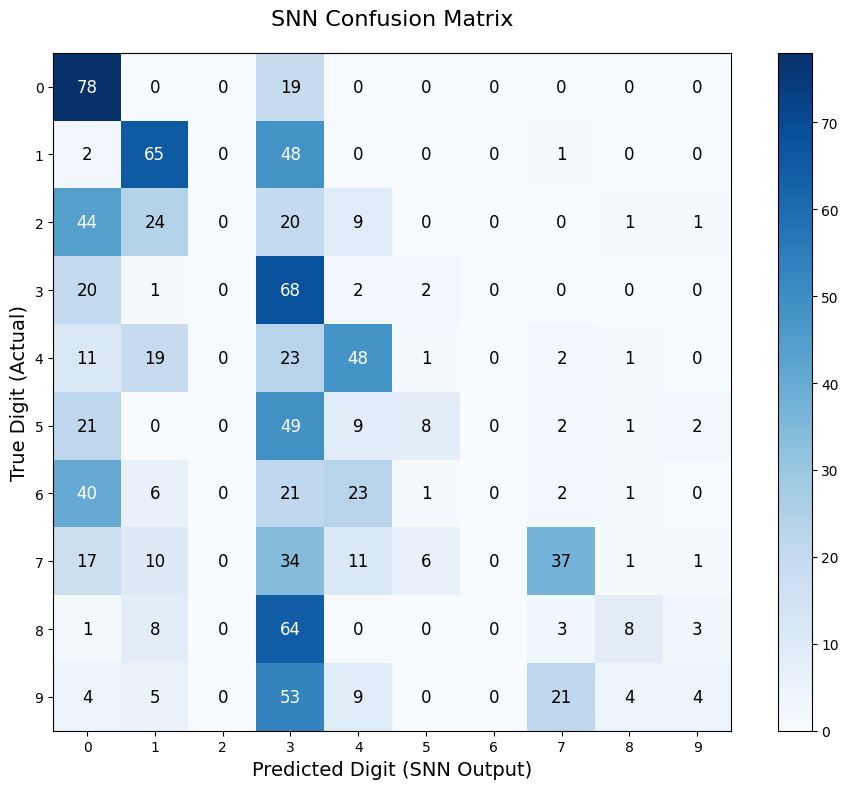

In [20]:
from sklearn.metrics import confusion_matrix
from utils import *
conf_matrix = confusion_matrix(actuals[valid_idx], predictions[valid_idx], labels=np.arange(10))
plot_confusion_matrix(conf_matrix)

In [ ]:
conf_matrix